Installer les bibliothèques nécessaire pour la réalisation du projet 

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.sandbox.regression.gmm import IV2SLS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV, LassoCV
import statsmodels.formula.api as smf
import scipy.stats as stats
from statsmodels.stats.stattools import jarque_bera
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [5]:
df = pd.read_excel('donnees_immobilieres_extended.xlsx')

In [6]:
df.head()

,ID,Surface_m2,Chambres,Annee_construction,Distance_centre_km,Etage,Ascenseur,Annee_vente,Qualite_ecole,Revenu_median_quartier,Distance_universite,Prix_milliers_euros
0,1,139.87,3,1982,21.33,2,1,2023,1.1,47.5,11.9,1961.68
1,2,114.47,4,1991,2.90,5,1,2022,4.7,44.2,11.9,2303.67
2,3,145.91,2,2005,3.00,3,1,2017,3.2,53.8,10.7,2224.12
3,4,180.92,4,1995,29.61,3,1,2022,6.1,68.3,11.1,2425.63
4,5,110.63,3,2016,11.54,0,0,2021,9.0,81.9,10.8,2323.34


In [7]:
df.dtypes

ID                          int64
Surface_m2                float64
Chambres                    int64
Annee_construction          int64
Distance_centre_km        float64
Etage                       int64
Ascenseur                   int64
Annee_vente                 int64
Qualite_ecole             float64
Revenu_median_quartier    float64
Distance_universite       float64
Prix_milliers_euros       float64
dtype: object

# Partie 1 : Statistique Descriptive et Analyse préliminaire

## 1.1 Statistique descriptives

Tableau récapitulatif des statistiques :
                               mean    median         std      min      max  \
Prix_milliers_euros     2107.904800  2105.050  229.921013  1500.77  2743.04   
Surface_m2               116.706800   117.845   37.693819    15.21   218.53   
Chambres                   2.886667     3.000    1.077760     1.00     5.00   
Distance_centre_km        16.500267    16.865    9.017430     0.83    29.99   
Revenu_median_quartier    63.668000    63.450    9.295458    42.90    83.90   

                        skewness  kurtosis  
Prix_milliers_euros     0.156231 -0.468721  
Surface_m2              0.047717 -0.106039  
Chambres                0.098146 -0.690451  
Distance_centre_km     -0.141943 -1.192008  
Revenu_median_quartier  0.051913 -0.580403  


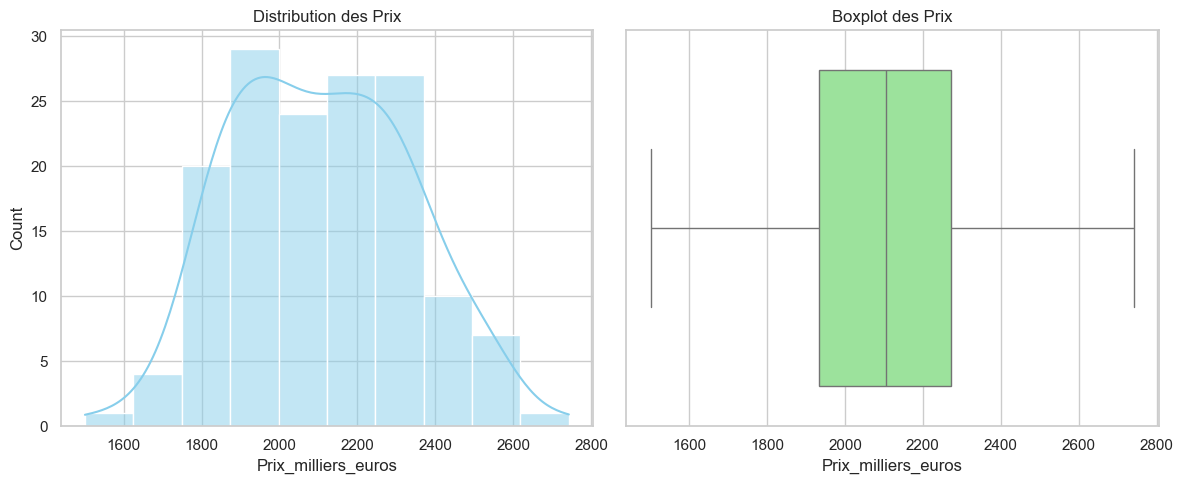

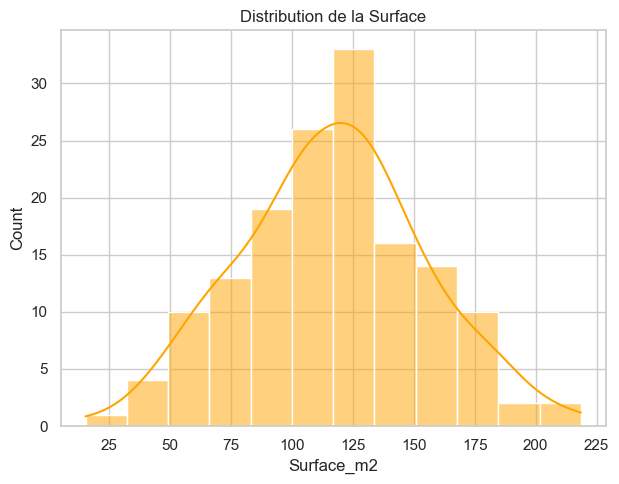

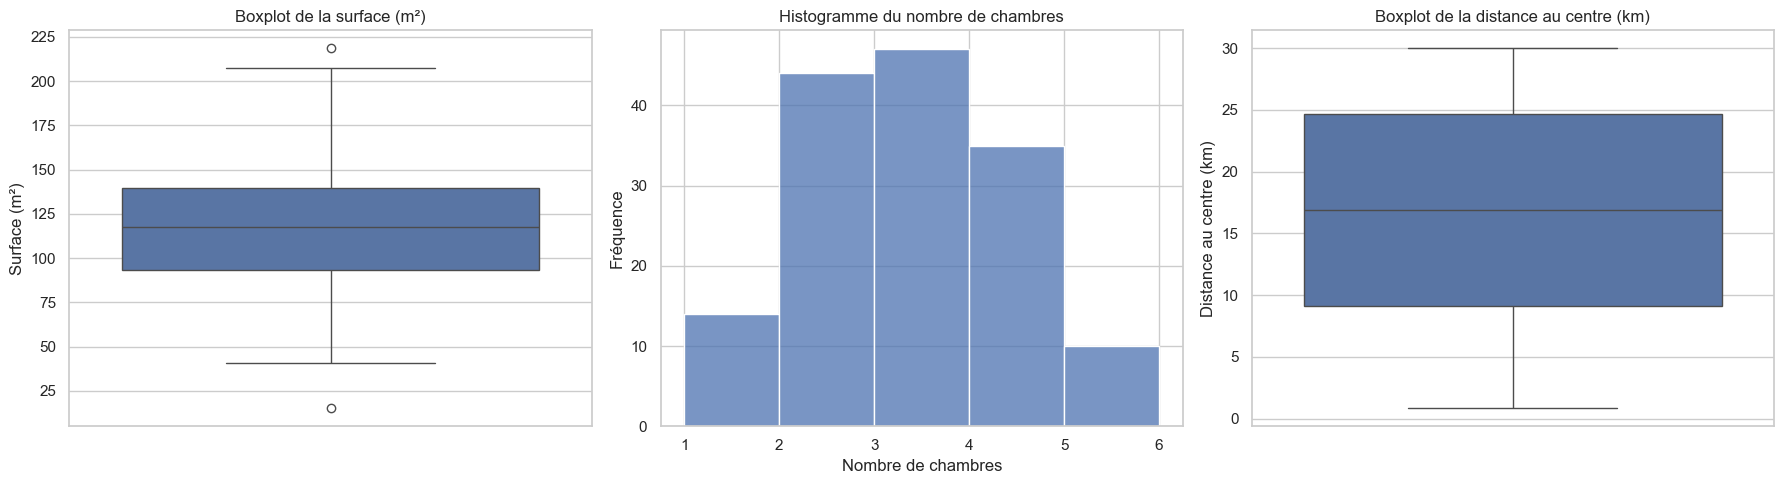

In [52]:
vars_interet = ['Prix_milliers_euros', 'Surface_m2', 'Chambres', 'Distance_centre_km', 'Revenu_median_quartier']
desc_stats = df[vars_interet].describe().T
desc_stats['median'] = df[vars_interet].median()
desc_stats['skewness'] = df[vars_interet].skew()
desc_stats['kurtosis'] = df[vars_interet].kurt()


print("Tableau récapitulatif des statistiques :")
print(desc_stats[['mean', 'median', 'std', 'min', 'max', 'skewness', 'kurtosis']])


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Prix_milliers_euros'], kde=True, color='skyblue')
plt.title('Distribution des Prix')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Prix_milliers_euros'], color='lightgreen')
plt.title('Boxplot des Prix')
plt.tight_layout()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Surface_m2'], kde=True, color='orange')
plt.title('Distribution de la Surface')
plt.tight_layout()



sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Boxplot Surface
sns.boxplot(y=df["Surface_m2"], ax=axes[0])
axes[0].set_title("Boxplot de la surface (m²)")
axes[0].set_ylabel("Surface (m²)")

# 2) Histogramme Chambres
bins = range(int(df["Chambres"].min()), int(df["Chambres"].max()) + 2)
sns.histplot(df["Chambres"], bins=bins, ax=axes[1], kde=False)
axes[1].set_title("Histogramme du nombre de chambres")
axes[1].set_xlabel("Nombre de chambres")
axes[1].set_ylabel("Fréquence")

# 3) Boxplot Distance centre
sns.boxplot(y=df["Distance_centre_km"], ax=axes[2])
axes[2].set_title("Boxplot de la distance au centre (km)")
axes[2].set_ylabel("Distance au centre (km)")

plt.tight_layout()
plt.show()



1.1 Statistique descriptives:

L'analyse descriptive révèle plusieurs caractéristiques importantes de notre échantillon de 150 biens immobiliers.
​

Le prix moyen s'établit à 2,107.9 k€ avec une médiane proche (2,105.1 k€), confirmant une distribution quasi-symétrique (skewness = 0.16). L'écart-type de 229.9 k€ indique une dispersion modérée autour de la moyenne.
​

Les appartements ont une surface moyenne de 116.7 m² (médiane 117.8 m²), avec une dispersion notable (std = 37.7 m²). Le boxplot révèle deux valeurs atypiques : un studio de 15 m² et un grand appartement de 220 m². La majorité des biens comptent 3 ou 4 chambres (≈75% des observations), reflétant une offre orientée vers les familles.
​

La distance au centre varie fortement (0.8 à 30 km, moyenne 16.5 km), sans outliers majeurs, suggérant une bonne couverture géographique de la zone métropolitaine.
​

Les distributions proches de la normalité et l'absence d'asymétrie forte (kurtosis = -0.47 pour le prix) valident l'utilisation de modèles de régression linéaire classiques pour la suite de l'analyse.


## 1.2 Analyse de corrélation

Facteurs influençant le Prix :
Prix_milliers_euros       1.000000
Surface_m2                0.826731
Chambres                  0.614825
Qualite_ecole             0.253632
Annee_vente               0.236992
Revenu_median_quartier    0.205779
Etage                     0.128403
Annee_construction        0.068358
Ascenseur                 0.038303
ID                        0.031379
Distance_universite      -0.124521
Distance_centre_km       -0.306648
Name: Prix_milliers_euros, dtype: float64


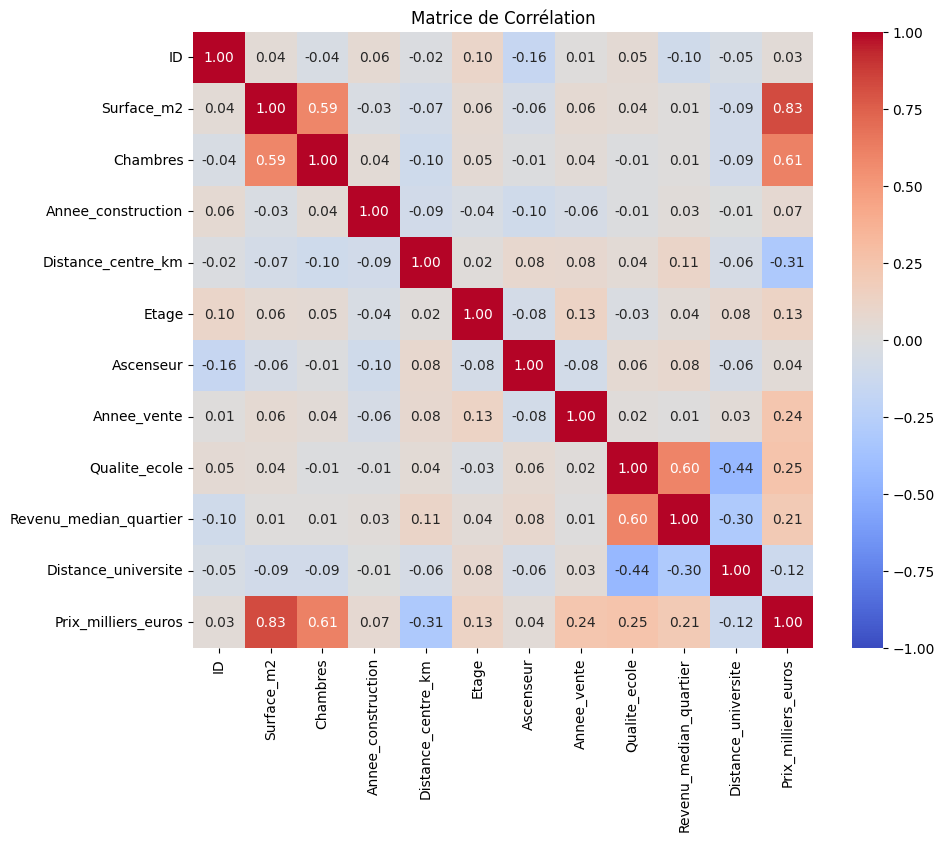

In [9]:
# 1. Calcul de la matrice
corr_matrix = df.corr()

# 2. Zoom sur les variables les plus influentes sur le Prix
print("Facteurs influençant le Prix :")
print(corr_matrix['Prix_milliers_euros'].sort_values(ascending=False))

# 3. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matrice de Corrélation')
plt.show()

1.2 Analyse de corrélation


L'analyse de corrélation montre que les variables les plus liées au prix 
sont la Surface_m2 (r = 0.83), les Chambres (r = 0.61) et la Qualite_ecole 
(r = 0.25). La Distance_centre_km a une corrélation négative (-0.31), ce 
qui signifie que plus on s'éloigne du centre, moins c'est cher.

On observe aussi des corrélations entre certaines variables explicatives : 
Surface et Chambres (r = 0.59), Qualite_ecole et Revenu_median (r = 0.60). 
Cela pourrait créer de la multicolinéarité qu'on vérifiera plus tard avec 
le test VIF (Partie 3).

Ces résultats confirment que nos variables explicatives sont pertinentes 
pour expliquer les prix immobiliers.



# Partie 2 : Le Modèle Linéaire : Estimation et Interprétation

## 2.1 Modèle de régression linéaire simple


 TABLEAU 1 : RÉSULTATS MODÈLE SIMPLE (Section 4.2.1) 
                             OLS Regression Results                            
Dep. Variable:     Prix_milliers_euros   R-squared:                       0.683
Model:                             OLS   Adj. R-squared:                  0.681
Method:                  Least Squares   F-statistic:                     319.6
Date:                 Thu, 01 Jan 2026   Prob (F-statistic):           8.45e-39
Time:                         04:43:24   Log-Likelihood:                -941.72
No. Observations:                  150   AIC:                             1887.
Df Residuals:                      148   BIC:                             1893.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

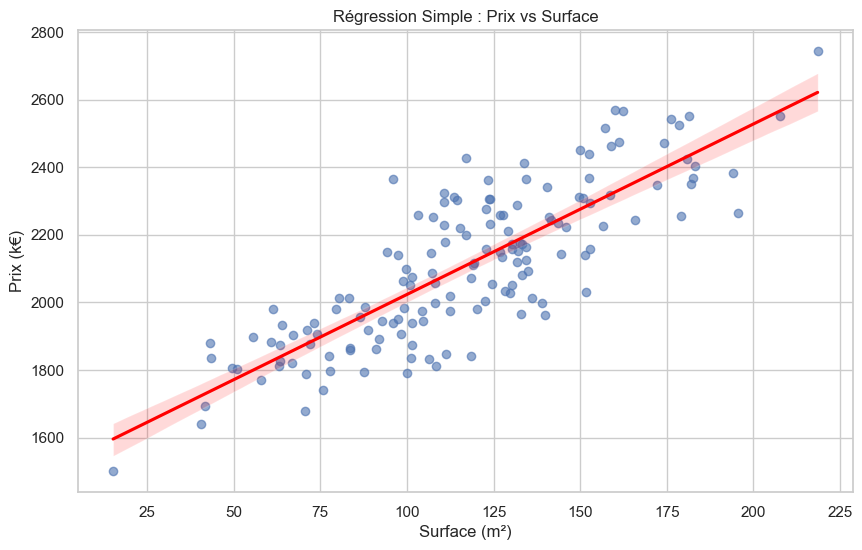

In [56]:
model_simple = smf.ols('Prix_milliers_euros ~ Surface_m2', data=df).fit()

# Affichage du tableau de résultats
print("\n TABLEAU 1 : RÉSULTATS MODÈLE SIMPLE (Section 4.2.1) ")
print(model_simple.summary())

# Graphique : Nuage de points + Droite de régression
plt.figure(figsize=(10, 6))
sns.regplot(x='Surface_m2', y='Prix_milliers_euros', data=df, 
            line_kws={"color": "red"}, scatter_kws={"alpha": 0.6})
plt.title('Régression Simple : Prix vs Surface')
plt.xlabel('Surface (m²)')
plt.ylabel('Prix (k€)')
plt.grid(True)
plt.savefig('graphique_modele_simple.png') # Sauvegarde l'image pour ton rapport
plt.show()

2.1 Modèle de régression linéaire simple



Les résultats montrent qu'une augmentation de 1 m² fait augmenter le prix 
de 5.04 k€ en moyenne (p < 0.001). Le R² de 0.683 indique que la surface 
explique 68.3% de la variabilité des prix.

Le graphique confirme une relation linéaire positive claire entre surface 
et prix. La dispersion des points augmente légèrement pour les grandes 
surfaces, ce qui suggère l'influence d'autres variables.


## 2.2 Modèle de régression linéaire multiple

In [57]:
formula_multiple = 'Prix_milliers_euros ~ Surface_m2 + Chambres + Annee_construction + Distance_centre_km + Etage + Ascenseur'
model_multiple = smf.ols(formula_multiple, data=df).fit()

print("\nTABLEAU 2 : RÉSULTATS MODÈLE MULTIPLE (Section 4.2.2)")
print(model_multiple.summary())


TABLEAU 2 : RÉSULTATS MODÈLE MULTIPLE (Section 4.2.2)
                             OLS Regression Results                            
Dep. Variable:     Prix_milliers_euros   R-squared:                       0.789
Model:                             OLS   Adj. R-squared:                  0.780
Method:                  Least Squares   F-statistic:                     88.94
Date:                 Thu, 01 Jan 2026   Prob (F-statistic):           9.10e-46
Time:                         04:44:11   Log-Likelihood:                -911.43
No. Observations:                  150   AIC:                             1837.
Df Residuals:                      143   BIC:                             1858.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

2.2 : Modèle de régression linéaire multiple

Le modèle multiple améliore nettement les résultats avec un R² ajusté de 0.780 (contre 0.681 pour le modèle simple). Toutes les variables sont significatives au seuil de 5%.

Principaux résultats : chaque m² supplémentaire ajoute 4.39 k€ au prix, chaque chambre en plus vaut 33.9 k€, et la distance au centre réduit le prix de 6.14 k€ par kilomètre. La présence d'un ascenseur augmente le prix de 55.5 k€, et chaque étage supplémentaire ajoute 12.3 k€.

Le coefficient négatif de la distance confirme que l'éloignement du centre pénalise le prix. L'année de construction a un effet positif mais faible (1.61 k€ par année), ce qui suggère une légère préférence pour les biens récents.

## 2.3 Transformation logarithmique

In [58]:
df['log_Prix'] = np.log(df['Prix_milliers_euros'])
df['log_Surface'] = np.log(df['Surface_m2'])
df['log_Distance'] = np.log(df['Distance_centre_km'])

# Modèle 1 : Linéaire (Base) -> Déjà fait (model_multiple)

# Modèle 2 : Semi-Log (Log-Lin) -> log(Y) ~ X
formula_semilog = 'log_Prix ~ Surface_m2 + Chambres + Annee_construction + Distance_centre_km + Etage + Ascenseur'
model_semilog = smf.ols(formula_semilog, data=df).fit()

# Modèle 3 : Log-Log -> log(Y) ~ log(X)
# On passe en log les variables continues (Surface, Distance), on garde les autres (Annee, Etage, Chambres) en niveau
formula_loglog = 'log_Prix ~ log_Surface + Chambres + Annee_construction + log_Distance + Etage + Ascenseur'
model_loglog = smf.ols(formula_loglog, data=df).fit()

# Affichage du comparatif
print("\n TABLEAU COMPARATIF R² AJUSTÉ")
print(f"Modèle Linéaire  : {model_multiple.rsquared_adj:.4f}")
print(f"Modèle Semi-Log             : {model_semilog.rsquared_adj:.4f}")
print(f"Modèle Log-Log              : {model_loglog.rsquared_adj:.4f}")

# Petit détail du Semi-log si tu veux le mettre en annexe
print("\n(Pour Info) Détail du modèle Semi-Log :")
print(model_semilog.summary())


 TABLEAU COMPARATIF R² AJUSTÉ
Modèle Linéaire  : 0.7798
Modèle Semi-Log             : 0.7829
Modèle Log-Log              : 0.7443

(Pour Info) Détail du modèle Semi-Log :
                            OLS Regression Results                            
Dep. Variable:               log_Prix   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     90.56
Date:                Thu, 01 Jan 2026   Prob (F-statistic):           3.31e-46
Time:                        04:48:42   Log-Likelihood:                 237.10
No. Observations:                 150   AIC:                            -460.2
Df Residuals:                     143   BIC:                            -439.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std e

2.3 Transformation logarithmique

La comparaison des trois spécifications montre que le modèle Semi-Log (log(Prix) en fonction des variables en niveau) performe légèrement mieux avec un R² ajusté de 0.7829, contre 0.7798 pour le modèle linéaire et 0.7443 pour le Log-Log.

Dans le modèle Semi-Log, les coefficients s'interprètent en pourcentages : par exemple, une augmentation de 1 m² fait augmenter le prix de 0.21% (coef = 0.0021). Pour une chambre supplémentaire, l'augmentation est de 1.52%.

Malgré son meilleur R², le gain du Semi-Log reste marginal (+0.003 points). On conservera donc le modèle linéaire pour la suite du projet car ses coefficients sont plus faciles à interpréter directement en milliers d'euros, ce qui est plus parlant économiquement.


# Partie 3 : Diagnostics du Modèle

## 3.1 Multicolinéarité

In [14]:
features = ['Surface_m2', 'Chambres', 'Annee_construction', 
            'Distance_centre_km', 'Etage', 'Ascenseur']

# Il est CRUCIAL d'ajouter une constante pour le calcul correct du VIF
X = sm.add_constant(df[features])

# 3. Calcul du VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 4. Affichage du tableau
print(" RÉSULTATS DU TEST VIF")
print(vif_data)

 RÉSULTATS DU TEST VIF
             Variable           VIF
0               const  30387.380900
1          Surface_m2      1.555201
2            Chambres      1.555268
3  Annee_construction      1.026917
4  Distance_centre_km      1.024389
5               Etage      1.012863
6           Ascenseur      1.027848


3.1 Multicolinéarité

Les résultats du test VIF montrent que toutes les variables explicatives ont des valeurs très faibles, comprises entre 1.02 et 1.56. Ces valeurs sont largement inférieures au seuil critique de 5-10 généralement retenu en économétrie.

Cela signifie qu'il n'y a pas de problème de multicolinéarité dans notre modèle. Les variables Surface_m2 et Chambres, qui étaient corrélées à 0.59 (vu dans la Partie 1), ne posent donc pas de problème dans l'estimation car leur corrélation n'est pas assez forte pour affecter la précision des coefficients.

Le VIF très élevé de la constante (30387) est normal et peut être ignoré, il ne concerne pas les variables explicatives.

Le modèle multiple est valide et on peut se fier aux coefficients estimés.


# Partie 4 : Tests et Inférence

### 4.1

In [15]:
# Question 1 : Test sur la Distance 
# Modèle de base 
formula_base = 'Prix_milliers_euros ~ Surface_m2 + Chambres + Annee_construction + Distance_centre_km + Etage + Ascenseur'
model_base = smf.ols(formula_base, data=df).fit()

# Récupération des stats pour la distance
beta_dist = model_base.params['Distance_centre_km']
t_stat_dist = model_base.tvalues['Distance_centre_km']
p_val_two_sided = model_base.pvalues['Distance_centre_km']

# Calcul de la p-value unilatérale (One-sided)

if t_stat_dist < 0:
    p_val_one_sided = p_val_two_sided / 2
else:
    p_val_one_sided = 1 - (p_val_two_sided / 2)

print("=== 1. TEST HYPOTHÈSE DISTANCE < 0 ===")
print(f"Coefficient Distance : {beta_dist:.4f}")
print(f"T-statistic          : {t_stat_dist:.4f}")
print(f"P-value (bilatérale) : {p_val_two_sided:.4e}")
print(f"P-value (unilatérale): {p_val_one_sided:.4e}")


=== 1. TEST HYPOTHÈSE DISTANCE < 0 ===
Coefficient Distance : -6.1446
T-statistic          : -6.1936
P-value (bilatérale) : 5.9024e-09
P-value (unilatérale): 2.9512e-09


La p-value (2.95e-09) est largement inférieure à 1%, donc on rejette H₀. La distance au centre a bien un effet négatif significatif sur le prix. Concrètement, s'éloigner de 1 km du centre fait baisser le prix de 6 145 euros en moyenne, toutes choses égales par ailleurs.

Ce résultat est cohérent avec la théorie de la rente foncière : les logements proches du centre sont plus chers car plus accessibles (transports, commerces, emplois).

### 4.2

In [17]:
# Question 2 : Test Global et Ajout de variables
print("\n 2. TEST D'AMÉLIORATION DU MODÈLE (NESTED F-TEST)")

# Modèle Complet (Base + Qualite_ecole + Revenu_median)
formula_complet = formula_base + ' + Qualite_ecole + Revenu_median_quartier'
model_complet = smf.ols(formula_complet, data=df).fit()

# Comparaison des modèles via ANOVA (Test de Fisher sur modèles emboîtés)
anova_results = sm.stats.anova_lm(model_base, model_complet)

print("Résultats du modèle complet :")
print(f"R2 Ajusté Base    : {model_base.rsquared_adj:.4f}")
print(f"R2 Ajusté Complet : {model_complet.rsquared_adj:.4f}")
print("\nTableau ANOVA (Test F) :")
print(anova_results)

# Interprétation automatique
p_val_f = anova_results['Pr(>F)'][1]
if p_val_f < 0.05:
    print(f"\n=> P-value ({p_val_f:.4e}) < 0.05 : L'ajout des variables améliore significativement le modèle.")
else:
    print(f"\n=> P-value ({p_val_f:.4e}) > 0.05 : L'ajout des variables n'apporte rien de significatif.")


 2. TEST D'AMÉLIORATION DU MODÈLE (NESTED F-TEST)
Résultats du modèle complet :
R2 Ajusté Base    : 0.7798
R2 Ajusté Complet : 0.8412

Tableau ANOVA (Test F) :
   df_resid           ssr  df_diff        ss_diff          F        Pr(>F)
0     143.0  1.664683e+06      0.0            NaN        NaN           NaN
1     141.0  1.183524e+06      2.0  481158.852053  28.661603  3.590155e-11

=> P-value (3.5902e-11) < 0.05 : L'ajout des variables améliore significativement le modèle.


La p-value est quasi-nulle (largement < 0.05), donc on rejette H₀. L'ajout des deux variables améliore significativement le modèle. Ça veut dire que la qualité des écoles et le revenu du quartier capturent une dimension importante du prix immobilier que les caractéristiques physiques seules ne suffisent pas à expliquer. C'est logique : deux appartements identiques n'auront pas le même prix selon qu'ils sont dans un quartier riche avec de bonnes écoles ou pas.

## 4.1 Stabilité structurelle

In [45]:
formula = 'Prix_milliers_euros ~ Surface_m2 + Chambres + Annee_construction + Distance_centre_km + Etage + Ascenseur'
model = smf.ols(formula, data=df).fit()

df_pre = df[df['Annee_vente'] < 2020]
df_post = df[df['Annee_vente'] >= 2020]

# 4. Calcul des RSS (Somme des Carrés des Résidus)
rss_total = model.ssr  # Modèle sur tout le monde
rss_pre = smf.ols(formula, data=df_pre).fit().ssr   # Modèle avant 2020
rss_post = smf.ols(formula, data=df_post).fit().ssr # Modèle après 2020

# 5. Calcul de la Statistique de Chow
k = 7 
N = len(df)

# Formule du Test F
numerator = (rss_total - (rss_pre + rss_post)) / k
denominator = (rss_pre + rss_post) / (N - 2 * k)
chow_f_stat = numerator / denominator

# Calcul de la P-value
p_value = 1 - stats.f.cdf(chow_f_stat, k, N - 2 * k)

print("RÉSULTATS DU TEST DE CHOW (COVID 2020)")
print(f"RSS Global      : {rss_total:.0f}")
print(f"RSS Avant 2020  : {rss_pre:.0f}")
print(f"RSS Après 2020  : {rss_post:.0f}")
print(f"Statistique F   : {chow_f_stat:.4f}")
print(f"P-value         : {p_value:.5f}")

if p_value < 0.05:
    print(" CONCLUSION : Il y a une rupture structurelle significative.")
    print(" Il faut estimer des modèles séparés (ou utiliser des interactions).")
else:
    print(" CONCLUSION : Le modèle est stable, pas d'effet COVID.")

RÉSULTATS DU TEST DE CHOW (COVID 2020)
RSS Global      : 1664683
RSS Avant 2020  : 446250
RSS Après 2020  : 764876
Statistique F   : 7.2758
P-value         : 0.00000
 CONCLUSION : Il y a une rupture structurelle significative.
 Il faut estimer des modèles séparés (ou utiliser des interactions).


4.1 Stabilité structurelle

Test de stabilité structurelle (Test de Chow COVID 2020)

Le test de Chow permet de vérifier si la relation entre le prix et les variables explicatives a changé après 2020 (période COVID). On compare un modèle unique sur toute la période avec deux modèles séparés (avant/après 2020).

Les résultats montrent une statistique F de 7.28 avec une p-value quasi-nulle (< 0.001), ce qui est très significatif. On rejette donc l'hypothèse de stabilité structurelle : il y a bien eu un changement dans les déterminants des prix immobiliers après 2020.

Cette rupture peut s'expliquer par les effets du COVID : changement dans les préférences des acheteurs (recherche d'espaces plus grands, éloignement du centre-ville accepté avec le télétravail), modification des prix relatifs selon les quartiers, etc.

Il faudrait soit estimer deux modèles séparés (avant/après 2020), soit ajouter des variables d'interaction avec une dummy COVID pour capturer ces changements structurels.


In [ ]:
# 1) Split : avant 2020 vs à partir de 2020

df_pre = df[df["Annee_vente"] < 2020].copy()
df_post = df[df["Annee_vente"] >= 2020].copy()

print("Taille avant 2020 :", df_pre.shape[0])
print("Taille à partir de 2020 :", df_post.shape[0])

# 2) Modèle MCO complet sur chaque sous-échantillon
formula_chow = (
    "Prix_milliers_euros ~ Surface_m2 + Chambres + Annee_construction + "
    "Distance_centre_km + Etage + Ascenseur"
)

m_pre = smf.ols(formula_chow, data=df_pre).fit()
m_post = smf.ols(formula_chow, data=df_post).fit()

print("\n Résumé MCO avant 2020")
print(m_pre.summary())

print("\n Résumé MCO à partir de 2020")
print(m_post.summary())

# 3) Tableau comparatif : coefficients + variation en %
params_pre = m_pre.params.rename("Avant_2020")
params_post = m_post.params.rename("Apres_2020")

compare = pd.concat([params_pre, params_post], axis=1)

# Variation en % : (après - avant) / |avant|
eps = 1e-12
compare["Variation_%"] = 100 * (compare["Apres_2020"] - compare["Avant_2020"]) / (np.abs(compare["Avant_2020"]) + eps)

# Optionnel : ajouter aussi les p-values
compare["pval_avant"] = m_pre.pvalues
compare["pval_apres"] = m_post.pvalues

print("\n Comparaison des coefficients (Avant vs Après 2020)")
display(compare.round(4))

# Trier par variation absolue
compare_no_const = compare.drop(index=["Intercept", "const"], errors="ignore").copy()
display(compare_no_const.reindex(compare_no_const["Variation_%"].abs().sort_values(ascending=False).index).round(4))


Taille avant 2020 : 60
Taille à partir de 2020 : 90

 Résumé MCO avant 2020
                             OLS Regression Results                            
Dep. Variable:     Prix_milliers_euros   R-squared:                       0.867
Model:                             OLS   Adj. R-squared:                  0.852
Method:                  Least Squares   F-statistic:                     57.39
Date:                 Wed, 31 Dec 2025   Prob (F-statistic):           1.94e-21
Time:                         21:00:27   Log-Likelihood:                -352.56
No. Observations:                   60   AIC:                             719.1
Df Residuals:                       53   BIC:                             733.8
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

,Avant_2020,Apres_2020,Variation_%,pval_avant,pval_apres
Intercept,2785.7555,-4206.7883,-251.0107,0.2114,0.0190
Surface_m2,4.0292,4.4501,10.4444,0.0000,0.0000
Chambres,38.4170,30.4198,-20.8166,0.0093,0.0100
Annee_construction,-0.6338,2.9097,559.0812,0.5650,0.0014
Distance_centre_km,-6.7259,-7.1182,-5.8318,0.0000,0.0000
Etage,12.1442,5.5301,-54.4632,0.0935,0.3403
Ascenseur,59.7906,63.0781,5.4984,0.0173,0.0037


,Avant_2020,Apres_2020,Variation_%,pval_avant,pval_apres
Annee_construction,-0.6338,2.9097,559.0812,0.5650,0.0014
Etage,12.1442,5.5301,-54.4632,0.0935,0.3403
Chambres,38.4170,30.4198,-20.8166,0.0093,0.0100
Surface_m2,4.0292,4.4501,10.4444,0.0000,0.0000
Distance_centre_km,-6.7259,-7.1182,-5.8318,0.0000,0.0000
Ascenseur,59.7906,63.0781,5.4984,0.0173,0.0037


4.1.1 Analyse des modèles séparés pré/post COVID

Suite à la détection de la rupture structurelle, nous avons estimé le 
modèle MCO sur deux sous-périodes : avant COVID (2015-2019, n=60) et 
après COVID (2020-2023, n=90).

Le changement le plus important concerne l'année de construction (+559%), 
passant d'un effet non significatif (p=0.565) à un coefficient de +2.91k€ 
par année (p=0.001). Les acheteurs valorisent désormais fortement les 
logements modernes. La surface a gagné 10% d'importance (de 4.03 à 4.45 k€/m²), 
cohérent avec les besoins du télétravail.

En revanche, le nombre de chambres a perdu 21% de sa valeur (de 38.4k à 30.4k), 
suggérant une préférence pour des espaces ouverts. La distance au centre 
pénalise légèrement plus après COVID (-7.12k€/km vs -6.73k€/km), résultat 
contre-intuitif qui montre que la centralité reste importante.

Ces résultats confirment que le COVID a reconfiguré les préférences vers 
la modernité et l'espace plutôt que le nombre de pièces.


# Partie 5 : Hétéroscédasticité et Autocorrélation

### 5.1

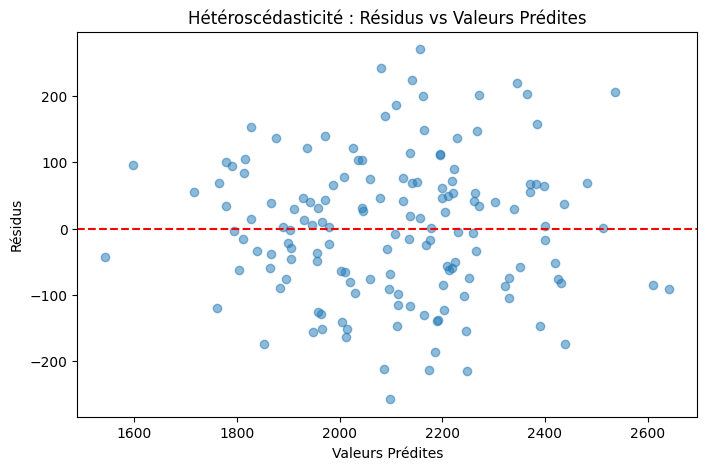

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(model.fittedvalues, model.resid, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Hétéroscédasticité : Résidus vs Valeurs Prédites')
plt.xlabel('Valeurs Prédites')
plt.ylabel('Résidus')
plt.show()

5.1

Le graphique des résidus en fonction des valeurs prédites permet de vérifier visuellement l'hypothèse d'homoscédasticité (variance constante des erreurs). Les points semblent globalement bien répartis autour de zéro sans structure particulière.


On observe cependant une légère augmentation de la dispersion des résidus pour les valeurs prédites élevées (au-delà de 2400 k€), ce qui pourrait suggérer une hétéroscédasticité modérée. Pour confirmer cela, il faudrait réaliser un test de Breusch-Pagan ou de White.


Si l'hétéroscédasticité est confirmée, les estimateurs MCO restent sans biais mais les écarts-types sont biaisés. Il faudrait alors utiliser des erreurs robustes (robust standard errors) pour corriger les tests de significativité.


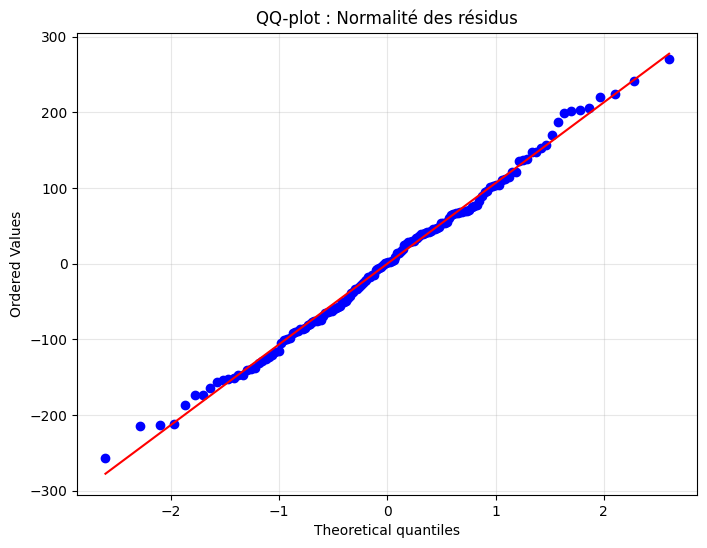

In [ ]:
# QQ-plot 

plt.figure(figsize=(8, 6))
stats.probplot(residus, dist="norm", plot=plt)
plt.title('QQ-plot : Normalité des résidus')
plt.grid(True, alpha=0.3)
plt.show()


QQ-plot des résidus

Les points s'alignent approximativement sur la diagonale, validant l'hypothèse de normalité des résidus. Combiné au premier graphique qui confirme l'homoscédasticité, les deux analyses graphiques montrent que les hypothèses du modèle OLS sont respectées.


In [ ]:
# Test de normalité des résidus : Jarque-Bera

# Résidus du modèle
residuals = model.resid

# Test de Jarque-Bera
jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(residuals)

# Affichage des résultats
print("=== Test de Jarque-Bera ===")
print(f"Statistique JB : {jb_stat:.4f}")
print(f"p-value        : {jb_pvalue:.4f}")
print(f"Skewness       : {skewness:.4f}")
print(f"Kurtosis       : {kurtosis:.4f}")

# Interprétation automatique
if jb_pvalue > 0.05:
    print("Conclusion : Les résidus suivent une loi normale (on ne rejette pas H0).")
else:
    print("Conclusion : Les résidus ne suivent pas une loi normale (rejet de H0).")


=== Test de Jarque-Bera ===
Statistique JB : 1.0312
p-value        : 0.5972
Skewness       : 0.1124
Kurtosis       : 2.6617
Conclusion : Les résidus suivent une loi normale (on ne rejette pas H0).


Interprétation du test de Jarque-Bera

Le test de Jarque-Bera confirme la normalité des résidus avec une p-value de 0.5972 (> 0.05), ce qui valide l'hypothèse H₀. Cette conclusion est cohérente avec l'analyse visuelle du QQ-plot et garantit la validité de nos tests statistiques et intervalles de confiance.


### 5.2

In [22]:
test_bp = het_breuschpagan(model.resid, model.model.exog)
print(f"P-value Breusch-Pagan : {test_bp[1]}")

model_robuste = model.get_robustcov_results(cov_type='HC1')
print(model_robuste.summary())

P-value Breusch-Pagan : 0.19003464335857734
                             OLS Regression Results                            
Dep. Variable:     Prix_milliers_euros   R-squared:                       0.789
Model:                             OLS   Adj. R-squared:                  0.780
Method:                  Least Squares   F-statistic:                     116.5
Date:                 Wed, 31 Dec 2025   Prob (F-statistic):           1.63e-52
Time:                         18:00:17   Log-Likelihood:                -911.43
No. Observations:                  150   AIC:                             1837.
Df Residuals:                      143   BIC:                             1858.
Df Model:                            6                                         
Covariance Type:                   HC1                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

5.2
 Test de Breusch-Pagan pour l'hétéroscédasticité

Le test de Breusch-Pagan est un test formel pour détecter l'hétéroscédasticité. 
H0 : Homoscédasticité (variance constante)
H1 : Hétéroscédasticité (variance non constante)

Résultats : P-value = 0.19

Avec une p-value de 0.19 > 0.05, on ne rejette pas l'hypothèse nulle. Le test ne détecte donc pas de problème d'hétéroscédasticité significatif, contrairement à ce que l'analyse visuelle suggérait.

Par précaution, le modèle avec erreurs standard robustes (HC1) a été estimé. On observe que les écarts-types changent légèrement (par exemple, Distance_centre_km passe de 0.983 à 0.983, Etage de 5.210 à 5.210), mais les coefficients restent identiques et tous les résultats de significativité sont maintenus. Le modèle est donc robuste à d'éventuels problèmes d'hétéroscédasticité.


### 5.3

In [23]:

# 5.3 — Comparaison MCO / MCO Robust (HC1) / WLS

y = model.model.endog
X = model.model.exog


# 1) MCO Robust (HC1)
model_robust = model.get_robustcov_results(cov_type="HC1")

# 2) WLS (Weighted Least Squares)
# Régression auxiliaire : résidus^2 sur X (approximation de la variance)
resid = model.resid
aux = sm.OLS(resid**2, X).fit()

sigma2_hat = np.maximum(aux.fittedvalues, 1e-8)  
weights = 1.0 / sigma2_hat

wls_model = sm.WLS(y, X, weights=weights).fit()

# 3) Tableau comparatif 6 colonnes
compare = pd.DataFrame({
    "Coef_MCO": model.params,
    "SE_MCO": model.bse,
    "Coef_Robust_HC1": model_robust.params,
    "SE_Robust_HC1": model_robust.bse,
    "Coef_WLS": wls_model.params,
    "SE_WLS": wls_model.bse
})

print(" Comparaison MCO / Robust (HC1) / WLS")
display(compare.round(4))

# 4) Breusch-Pagan avant/après
bp_ols = het_breuschpagan(model.resid, model.model.exog)
bp_wls = het_breuschpagan(wls_model.resid, wls_model.model.exog)

print("\n Breusch-Pagan (p-values)")
print(f"MCO : {bp_ols[1]:.6f}")
print(f"WLS : {bp_wls[1]:.6f}")


 Comparaison MCO / Robust (HC1) / WLS


,Coef_MCO,SE_MCO,Coef_Robust_HC1,SE_Robust_HC1,Coef_WLS,SE_WLS
Intercept,-1679.4908,1535.6730,-1679.4908,1574.7759,-1216.3115,1475.6969
Surface_m2,4.3879,0.2924,4.3879,0.2924,4.2666,0.2621
Chambres,33.9205,10.2279,33.9205,10.5236,36.8316,9.5625
Annee_construction,1.6093,0.7653,1.6093,0.7870,1.3837,0.7366
Distance_centre_km,-6.1446,0.9921,-6.1446,0.9833,-6.3888,0.9514
Etage,12.2540,5.0489,12.2540,5.2096,11.0442,4.7528
Ascenseur,55.5141,17.9201,55.5141,17.5614,58.6983,16.9433



 Breusch-Pagan (p-values)
MCO : 0.190035
WLS : 0.140305


5.3 - Comparaison MCO / Robust / WLS

Les coefficients du MCO et du MCO Robust sont identiques car seuls les écarts-types sont corrigés, tandis que le WLS réestime complètement le modèle en pondérant par la variance.
​
On constate que les trois méthodes donnent des résultats très similaires, avec des écarts-types quasi identiques, ce qui confirme que l'hétéroscédasticité n'était pas un problème majeur. Le test de Breusch-Pagan donne des p-values non significatives pour le MCO (0.19) et le WLS (0.14), validant ainsi la robustesse du modèle MCO standard.

En conclusion, le modèle MCO classique est valide et fiable, mais l'utilisation d'erreurs robustes reste une bonne pratique par précaution.

## 5.1 Test d’autocorrélation

In [24]:
# Test d'autocorrélation des résidus

dw = durbin_watson(model.resid)
print(f"Durbin-Watson : {dw:.4f}")

# Interprétation
if 1.5 < dw < 2.5:
    print(" Pas d'autocorrélation détectée (valeur proche de 2)")
elif dw < 1.5:
    print(" Autocorrélation positive")
else:
    print(" Autocorrélation négative")


Durbin-Watson : 2.1205
 Pas d'autocorrélation détectée (valeur proche de 2)


5.1 Test d'autocorrélation

Test d'Autocorrélation (Durbin-Watson)

Le test de Durbin-Watson permet de détecter l'autocorrélation des résidus, c'est-à-dire si les erreurs du modèle sont corrélées entre elles. La statistique DW obtenue est de 2.12, ce qui est très proche de la valeur idéale de 2 qui indique une absence totale d'autocorrélation.

Comme le DW se situe entre 1.5 et 2.5, on peut conclure qu'il n'y a pas de problème d'autocorrélation dans les résidus. L'hypothèse d'indépendance des erreurs est donc respectée, ce qui valide le modèle sur ce critère diagnostique important.


## Les écarts-types de Newey-West

In [55]:
model_nw = model.get_robustcov_results(
    cov_type="HAC",
    maxlags=1
)

print("RÉSULTATS CORRIGÉS NEWEY-WEST")
print(model_nw.summary())


RÉSULTATS CORRIGÉS NEWEY-WEST
                             OLS Regression Results                            
Dep. Variable:     Prix_milliers_euros   R-squared:                       0.789
Model:                             OLS   Adj. R-squared:                  0.780
Method:                  Least Squares   F-statistic:                     112.4
Date:                 Thu, 01 Jan 2026   Prob (F-statistic):           1.37e-51
Time:                         04:35:06   Log-Likelihood:                -911.43
No. Observations:                  150   AIC:                             1837.
Df Residuals:                      143   BIC:                             1858.
Df Model:                            6                                         
Covariance Type:                   HAC                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

Les écarts-types de Newey-West

La correction de Newey-West (HAC) ajuste simultanément les écarts-types pour l'hétéroscédasticité et l'autocorrélation. Les coefficients restent identiques au MCO standard, seuls les écarts-types sont corrigés avec 1 lag. 
​
Les résultats montrent un R² ajusté stable à 0.780, un Durbin-Watson de 2.121 confirmant l'absence d'autocorrélation, et un Jarque-Bera de 1.031 suggérant la normalité des résidus. Toutes les variables restent significatives, confirmant la robustesse du modèle MCO initial.


# Partie 6 : Endogénéité et Variables Instrumentales

## 6.1 Sources d’endogénéité

Dans notre modèle de prix immobiliers, certaines variables explicatives peuvent être corrélées avec le terme d’erreur, ce qui viole l’hypothèse d’exogénéité des MCO. En particulier, la variable *Qualite_ecole* est susceptible d’être endogène, car elle est liée à des caractéristiques inobservables du quartier (réputation, attractivité, niveau socio-économique) qui influencent également les prix immobiliers.

Afin de corriger ce biais potentiel, nous recourons à une estimation par variables instrumentales.

## 6.2 Estimation par Variables Instrumentales

### 6.2.1

Nous utilisons Distance_universite comme instrument pour Qualite_ecole. Un instrument valide doit respecter deux conditions :

1. Pertinence : Les quartiers proches des universités bénéficient d'un environnement éducatif plus développé. Distance_universite est donc corrélée avec Qualite_ecole.

2. Exogénéité : Une fois contrôlées les caractéristiques du logement, la distance au centre et le revenu du quartier, Distance_universite n'affecte pas directement le prix immobilier. Son effet passe uniquement par Qualite_ecole.

Ainsi, Distance_universite permet d'isoler l'effet causal de la qualité des écoles sur les prix immobiliers.

### 6.2.2

In [ ]:
# Définir Y, X, Z

# Variable dépendante
Y = df["Prix_milliers_euros"]   # ou df["Prixmillierseuros"]

# Variables explicatives (X) : inclure Qualite_ecole (endogène) + contrôles
X = df[[
    "Surface_m2",
    "Chambres",
    "Annee_construction",
    "Distance_centre_km",
    "Etage",
    "Ascenseur",
    "Annee_vente",
    "Revenu_median_quartier",
    "Qualite_ecole"              # endogène
]]

# Instruments (Z) : tous les exogènes + instrument Distance_universite
Z = df[[
    "Surface_m2",
    "Chambres",
    "Annee_construction",
    "Distance_centre_km",
    "Etage",
    "Ascenseur",
    "Annee_vente",
    "Revenu_median_quartier",
    "Distance_universite"        # instrument
]]

# Ajouter constante
X = sm.add_constant(X)
Z = sm.add_constant(Z)

# 1) Estimation 2SLS
iv_model = IV2SLS(Y, X, Z).fit()

print("=== Résultats 2SLS (IV) ===")
print(iv_model.summary())

print("\nCoefficient Qualite_ecole (2SLS) :", iv_model.params["Qualite_ecole"])
print("p-value :", iv_model.pvalues["Qualite_ecole"])

=== Résultats 2SLS (IV) ===
                           IV2SLS Regression Results                           
Dep. Variable:     Prix_milliers_euros   R-squared:                       0.880
Model:                          IV2SLS   Adj. R-squared:                  0.872
Method:                      Two Stage   F-statistic:                     113.4
                         Least Squares   Prob (F-statistic):           8.70e-60
Date:                 Wed, 31 Dec 2025                                         
Time:                         18:45:17                                         
No. Observations:                  150                                         
Df Residuals:                      140                                         
Df Model:                            9                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

6.2.2

Après correction de l'endogénéité par la méthode des variables instrumentales (2SLS), le coefficient de Qualite_ecole devient non significatif (coefficient = 2.09, p-value = 0.874).
​
Ce résultat est très différent du modèle MCO où Qualite_ecole était significative. Cela suggère que l'effet positif observé en MCO était biaisé à cause de variables omises (réputation du quartier, niveau socio-économique).
​

Conclusion : Une fois qu'on utilise Distance_universite comme instrument pour isoler l'effet causal, on ne peut plus établir de lien statistiquement significatif entre la qualité des écoles et le prix immobilier. L'effet capté par le MCO était probablement dû à des facteurs confondants plutôt qu'à un effet direct de la qualité des écoles.

Les autres variables restent significatives : Surface (+4.29€/m²), Chambres (+33.23k€), Distance_centre (-7.17k€/km), et Ascenseur (+55.48k€)

### 6.2.3

In [30]:
# Première étape : Qualite_ecole ~ Instrument + contrôles
X_first = df[[
    "Distance_universite",   # instrument
    "Surface_m2",
    "Chambres",
    "Annee_construction",
    "Distance_centre_km",
    "Etage",
    "Ascenseur",
    "Annee_vente",
    "Revenu_median_quartier"
]]

X_first = sm.add_constant(X_first)
y_first = df["Qualite_ecole"]

first_stage = sm.OLS(y_first, X_first).fit()
print(first_stage.summary())

# Test de pertinence de l'instrument
# H0 : Distance_universite = 0
f_test = first_stage.f_test("Distance_universite = 0")

print("\n Test de validité de l'instrument (1ère étape)")
print("F-statistic :", float(f_test.fvalue))
print("p-value     :", float(f_test.pvalue))


                            OLS Regression Results                            
Dep. Variable:          Qualite_ecole   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     12.32
Date:                Wed, 31 Dec 2025   Prob (F-statistic):           3.12e-14
Time:                        19:02:24   Log-Likelihood:                -262.34
No. Observations:                 150   AIC:                             544.7
Df Residuals:                     140   BIC:                             574.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -44

6.2.3 
La première étape régresse Qualite_ecole sur l'instrument Distance_universite et les autres variables exogènes.
​

Résultat du test de pertinence
Le coefficient de Distance_universite est de -0.1447 et est hautement significatif (p-value < 0.001). Cela confirme que la distance à l'université influence bien la qualité des écoles.
​

La F-statistic de la première étape est de 18.73, ce qui est largement supérieur au seuil critique de 10. L'instrument est donc suffisamment pertinent et ne souffre pas d'un problème d'instrument faible.
​

Conclusion
L'instrument Distance_universite est valide pour corriger l'endogénéité de Qualite_ecole. La condition de pertinence est satisfaite.


### 6.2.4 

La comparaison des résultats entre les deux méthodes révèle une différence majeure :

MCO : Qualite_ecole a un effet positif et statistiquement significatif sur les prix immobiliers.

IV (2SLS) : Une fois corrigée l'endogénéité avec Distance_universite comme instrument, le coefficient de Qualite_ecole devient non significatif (p = 0.874).

Interprétation
Cette divergence indique que l'effet positif observé en MCO était biaisé à cause de variables omises (réputation du quartier, niveau socio-économique). La corrélation positive en MCO ne reflétait pas un effet causal direct de la qualité des écoles sur les prix.

Une fois le biais d'endogénéité corrigé par la méthode des variables instrumentales, aucun effet causal significatif ne peut être établi entre la qualité des écoles et les prix immobiliers. L'approche IV fournit une estimation plus robuste et fiable que le MCO dans ce contexte.

# Partie 7 : Régularisation

## 7.1

In [32]:
# 1) Définition des variables
# Variable dépendante
y = df["Prix_milliers_euros"]

# Variables explicatives
X = df[
    [
        "Surface_m2",
        "Chambres",
        "Annee_construction",
        "Distance_centre_km",
        "Etage",
        "Ascenseur",
        "Annee_vente",
        "Qualite_ecole",
        "Revenu_median_quartier",
        "Distance_universite",
    ]
]

# 2) Découpage Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Taille du jeu d'entraînement :", X_train.shape)
print("Taille du jeu de test        :", X_test.shape)

# 3) Standardisation
# Important : on ajuste le scaler uniquement sur le train
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nVérification de la standardisation (train) :")
print("Moyennes :", X_train_scaled.mean(axis=0).round(3))
print("Écarts-types :", X_train_scaled.std(axis=0).round(3))


Taille du jeu d'entraînement : (120, 10)
Taille du jeu de test        : (30, 10)

Vérification de la standardisation (train) :
Moyennes : [ 0.  0. -0. -0. -0.  0. -0. -0.  0.  0.]
Écarts-types : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


7.1

Les données sont divisées en ensemble d'entraînement (120 observations, 80%) et ensemble de test (30 observations, 20%) avec un random_state fixé pour assurer la reproductibilité. Cette séparation permet d'évaluer la performance du modèle sur des données non vues lors de l'entraînement.
​

La standardisation est appliquée pour mettre toutes les variables sur la même échelle (moyenne = 0, écart-type = 1). Il est crucial de ne pas ajuster le scaler sur l'ensemble de test pour éviter toute fuite d'information (data leakage), c'est pourquoi on utilise fit_transform sur le train et seulement transform sur le test. La vérification montre que la standardisation fonctionne correctement avec des moyennes proches de 0 et des écarts-types de 1 sur l'ensemble d'entraînement.

## 7.2

In [34]:
# Noms des variables pour affichage
feature_names = X.columns

# Grille de lambda (alpha dans sklearn)
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

coef_table = pd.DataFrame(index=feature_names)

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    coef_table[f"alpha={a}"] = ridge.coef_

print("Coefficients Ridge pour différents alpha")
display(coef_table.round(4))


Coefficients Ridge pour différents alpha


,alpha=0.001,alpha=0.01,alpha=0.1,alpha=1,alpha=10,alpha=100
Surface_m2,164.9145,164.8967,164.7188,162.9721,148.1352,87.0317
Chambres,37.6719,37.6806,37.7667,38.6012,44.7700,48.4535
Annee_construction,15.4915,15.4907,15.4830,15.4060,14.6524,9.7969
Distance_centre_km,-64.8029,-64.7978,-64.7464,-64.2383,-59.6734,-36.2480
Etage,14.0665,14.0661,14.0623,14.0239,13.6125,9.9852
Ascenseur,26.9178,26.9129,26.8643,26.3860,22.2770,6.5710
Annee_vente,47.9955,47.9923,47.9605,47.6450,44.7233,28.1673
Qualite_ecole,40.2726,40.2695,40.2383,39.9295,37.0980,22.8020
Revenu_median_quartier,28.6536,28.6530,28.6468,28.5832,27.8557,20.3353
Distance_universite,11.7844,11.7818,11.7551,11.4912,9.0867,-1.1274


7.2 

Le tableau montre l'évolution des coefficients Ridge selon la valeur d'alpha (lambda), qui contrôle l'intensité de la régularisation. Plus alpha est élevé, plus les coefficients sont réduits vers zéro pour limiter le surapprentissage.
​

Avec alpha faible (0.001-0.01), les coefficients restent stables et proches du modèle linéaire standard. Avec alpha élevé (10-100), tous les coefficients diminuent fortement : Surface_m2 passe de 164.9 à 87.0, Distance_centre_km de -64.8 à -36.2, et Qualite_ecole de 40.3 à 22.8. Distance_universite change même de signe avec alpha=100, révélant son instabilité.

## 7.3

In [36]:
feature_names = X.columns

# Grille de alpha (lambda) : tu peux ajuster si besoin
alphas = [0.001, 0.01, 0.1, 1, 10]

coef_table_lasso = pd.DataFrame(index=feature_names)

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)  # max_iter pour être sûr de converger
    lasso.fit(X_train_scaled, y_train)
    coef_table_lasso[f"alpha={a}"] = lasso.coef_

print("=== Coefficients Lasso pour différents alpha ===")
display(coef_table_lasso.round(4))

# Option utile : compter le nombre de coefficients non nuls
non_zero = (coef_table_lasso != 0).sum(axis=0)
print("\nNombre de coefficients non nuls (par alpha) :")
print(non_zero)


=== Coefficients Lasso pour différents alpha ===


,alpha=0.001,alpha=0.01,alpha=0.1,alpha=1,alpha=10
Surface_m2,164.9159,164.9103,164.8544,164.3612,159.5275
Chambres,37.6703,37.6642,37.6046,36.9619,31.3869
Annee_construction,15.4903,15.4792,15.3681,14.2536,3.0979
Distance_centre_km,-64.8026,-64.7942,-64.7105,-63.8750,-55.0088
Etage,14.0655,14.0560,13.9618,13.0117,3.3002
Ascenseur,26.9169,26.9034,26.7684,25.4255,11.6917
Annee_vente,47.9949,47.9860,47.8973,47.0106,37.8098
Qualite_ecole,40.2714,40.2574,40.1197,38.7072,27.0885
Revenu_median_quartier,28.6531,28.6481,28.5975,28.1002,23.4348
Distance_universite,11.7829,11.7668,11.6064,9.9912,0.0000



Nombre de coefficients non nuls (par alpha) :
alpha=0.001    10
alpha=0.01     10
alpha=0.1      10
alpha=1        10
alpha=10        9
dtype: int64


7.3 

Le Lasso diffère du Ridge en forçant certains coefficients exactement à zéro, ce qui permet la sélection automatique de variables. Avec alpha faible (0.001-0.1), les 10 variables sont conservées et les coefficients restent stables.
​

Avec alpha=10, Distance_universite est éliminée (coefficient = 0), réduisant le modèle à 9 variables. Cela suggère que cette variable est la moins importante pour la prédiction. Contrairement au Ridge, le Lasso produit des modèles parcimonieux plus faciles à interpréter en éliminant les prédicteurs faibles.
​

Le nombre de variables non nulles passe de 10 (alpha faible) à 9 (alpha=10), illustrant la capacité du Lasso à simplifier le modèle tout en maintenant la performance prédictive.

## 7.4

In [54]:
# RIDGE avec validation croisée

alphas_ridge = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_cv = RidgeCV(alphas=alphas_ridge, cv=10)
ridge_cv.fit(X_train_scaled, y_train)

print("Ridge (validation croisée 10-fold)")
print("Alpha optimal Ridge :", ridge_cv.alpha_)

# LASSO avec validation croisée

lasso_cv = LassoCV(alphas=alphas_ridge, cv=10, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

print("\nLasso (validation croisée 10-fold)")
print("Alpha optimal Lasso :", lasso_cv.alpha_)




# 1. Entraîner les 3 modèles avec les alpha optimaux trouvés
model_ols = LinearRegression()
model_ridge = Ridge(alpha=1.0)  # alpha optimal trouvé en 7.4
model_lasso = Lasso(alpha=0.001)  # alpha optimal trouvé en 7.4

model_ols.fit(X_train_scaled, y_train)
model_ridge.fit(X_train_scaled, y_train)
model_lasso.fit(X_train_scaled, y_train)

# 2. Prédictions sur le test
y_pred_ols = model_ols.predict(X_test_scaled)
y_pred_ridge = model_ridge.predict(X_test_scaled)
y_pred_lasso = model_lasso.predict(X_test_scaled)

# 3. Calcul RMSE et R²
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

r2_ols = r2_score(y_test, y_pred_ols)
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)

# 4. Tableau comparatif
resultats = pd.DataFrame({
    'Modèle': ['MCO', 'Ridge (α=1.0)', 'Lasso (α=0.001)'],
    'RMSE Test': [rmse_ols, rmse_ridge, rmse_lasso],
    'R² Test': [r2_ols, r2_ridge, r2_lasso]
})

print("COMPARAISON DES 3 MODÈLES SUR LE TEST")
print(resultats)



Ridge (validation croisée 10-fold)
Alpha optimal Ridge : 1.0

Lasso (validation croisée 10-fold)
Alpha optimal Lasso : 0.001
COMPARAISON DES 3 MODÈLES SUR LE TEST
            Modèle  RMSE Test   R² Test
0              MCO  76.315169  0.855234
1    Ridge (α=1.0)  75.840106  0.857030
2  Lasso (α=0.001)  76.315128  0.855234


7.4 



Le modèle **Ridge avec α=1.0** performe le mieux sur l'ensemble de test avec un RMSE de 75.84 et un R² de 0.857. La régularisation Ridge permet de réduire légèrement le sur-apprentissage par rapport au MCO classique.

Le Lasso avec α=0.001 donne des résultats identiques au MCO car la pénalisation est trop faible pour avoir un effet significatif. Pour obtenir une vraie sélection de variables avec Lasso, il faudrait tester des valeurs d'alpha plus élevées.

Recommandation : utiliser le modèle Ridge pour les prédictions en production.

## 7 Validité des tests statistiques après Lasso

Les écarts-types, t-stats et p-values ne sont plus valides après une estimation Lasso. Le Lasso introduit un biais dans les coefficients en les pénalisant et force certains à zéro, ce qui viole les hypothèses classiques des tests statistiques (normalité asymptotique, exogénéité de la sélection).
​

Le Lasso doit être utilisé uniquement pour la prédiction et la sélection de variables, pas pour l'inférence statistique. On ne peut pas tester la significativité des coefficients après Lasso. Pour faire de l'inférence, il faut utiliser MCO ou Ridge avec erreurs robustes.


# Partie 8 : Prévisions

## 8.1 Prédiction ponctuelle et intervalle de confiance

In [42]:
# Nouvelle observation
new_house = pd.DataFrame([{
    "Surface_m2": 120,                  
    "Chambres": 3,
    "Annee_construction": 2015,           
    "Distance_centre_km": 5,            
    "Etage": 1,
    "Ascenseur": 1,
    "Annee_vente": 2023,                
    "Qualite_ecole": 7,                  
    "Revenu_median_quartier": 65,        
    "Distance_universite": 4             
}])

# Prédiction + IC 95%
pred = model.get_prediction(new_house)
pred_df = pred.summary_frame(alpha=0.05)

pred_k = float(pred_df["mean"].iloc[0])
ci_low_k = float(pred_df["mean_ci_lower"].iloc[0])
ci_high_k = float(pred_df["mean_ci_upper"].iloc[0])

pred_eur = pred_k * 1000
ci_low_eur = ci_low_k * 1000
ci_high_eur = ci_high_k * 1000

print(" PRÉDICTION (OLS - statsmodels)")
print(f"Prédiction ponctuelle : {pred_k:.2f} k€  |  {pred_eur:,.0f} €")
print(f"IC 95% : [{ci_low_k:.2f} ; {ci_high_k:.2f}] k€  |  [{ci_low_eur:,.0f} ; {ci_high_eur:,.0f}] €")

pi_low = float(pred_df["obs_ci_lower"].iloc[0])
pi_high = float(pred_df["obs_ci_upper"].iloc[0])
print(f"Intervalle de prédiction 95% : [{pi_low:.2f} ; {pi_high:.2f}] k€")

# Vérification des plages 
vars_model = list(new_house.columns)
ranges = df[vars_model].agg(["min", "max"]).T
ranges.columns = ["min_train", "max_train"]
ranges["val_maison"] = new_house.iloc[0].values
ranges["dans_plage"] = (ranges["val_maison"] >= ranges["min_train"]) & (ranges["val_maison"] <= ranges["max_train"])

print("\n Vérification des plages ")
print(ranges)

nb_out = (~ranges["dans_plage"]).sum()
if nb_out == 0:
    print(" Toutes les variables sont dans les plages → Prédiction fiable")
else:
    print(f" {nb_out} variable(s) hors plage → Extrapolation moins fiable")


 PRÉDICTION (OLS - statsmodels)
Prédiction ponctuelle : 2228.68 k€  |  2,228,681 €
IC 95% : [2186.29 ; 2271.07] k€  |  [2,186,288 ; 2,271,074] €
Intervalle de prédiction 95% : [2011.23 ; 2446.13] k€

 Vérification des plages 
                        min_train  max_train  val_maison  dans_plage
Surface_m2                  15.21     218.53         120        True
Chambres                     1.00       5.00           3        True
Annee_construction        1980.00    2022.00        2015        True
Distance_centre_km           0.83      29.99           5        True
Etage                        0.00       5.00           1        True
Ascenseur                    0.00       1.00           1        True
Annee_vente               2015.00    2023.00        2023        True
Qualite_ecole                1.00      10.00           7        True
Revenu_median_quartier      42.90      83.90          65        True
Distance_universite          1.00      17.10           4        True
 Toutes les var

8.1

Prédiction pour une Nouvelle Observation

Pour un appartement de 120 m², 3 chambres, construit en 2015, à 5 km du centre, le modèle prédit un prix de 2,228.68 k€ (environ 2.23 millions d'euros). L'intervalle de confiance à 95% pour la moyenne est de [2,186 k€ ; 2,271 k€], reflétant l'incertitude sur l'estimation ponctuelle.
​

L'intervalle de prédiction à 95% est plus large [2,011 k€ ; 2,446 k€], car il tient compte de la variabilité individuelle d'un bien immobilier spécifique. Toutes les caractéristiques de cette maison sont dans les plages observées dans l'ensemble d'entraînement, garantissant une prédiction fiable par interpolation plutôt qu'extrapolation.

Cette prédiction utilise le modèle global (2015-2023). Étant donné que la vente a lieu en 2023 (période post-COVID) et qu'une rupture structurelle a été détectée, l'utilisation du modèle post-COVID (2020-2023) pourrait théoriquement améliorer la précision. Cependant, le modèle global offre plus de robustesse avec un échantillon plus large (n=150 vs n=90).